In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150
})

MAIN_COLOR = "#1f4e79"

In [36]:
from pathlib import Path

data_path = Path("../Data")

csv_files = sorted(data_path.glob("*.csv"))

print(f"Found {len(csv_files)} files")

Found 21 files


In [37]:
# Combine everything into a single DataFrame
dfs = []

for file in csv_files:
    temp = pd.read_csv(file)
    dfs.append(temp)

shots = pd.concat(dfs, ignore_index=True)

print(shots.shape)

(4231262, 26)


In [38]:
shots.head()


,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Above the Break 3,Left Side Center,LC,24+ ft.,20.0,21.35,25,6,0,0
1,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,6,0,2
2,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Mid-Range,Left Side Center,LC,16-24 ft.,13.3,24.45,23,6,0,9
3,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Left Side,L,16-24 ft.,16.4,13.95,18,6,0,31
4,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Right Side,R,16-24 ft.,-15.8,7.85,16,6,0,55


In [39]:
shots.info()

<class 'pandas.DataFrame'>
RangeIndex: 4231262 entries, 0 to 4231261
Data columns (total 26 columns):
 #   Column          Dtype  
---  ------          -----  
 0   SEASON_1        int64  
 1   SEASON_2        str    
 2   TEAM_ID         int64  
 3   TEAM_NAME       str    
 4   PLAYER_ID       int64  
 5   PLAYER_NAME     str    
 6   POSITION_GROUP  str    
 7   POSITION        str    
 8   GAME_DATE       str    
 9   GAME_ID         int64  
 10  HOME_TEAM       str    
 11  AWAY_TEAM       str    
 12  EVENT_TYPE      str    
 13  SHOT_MADE       bool   
 14  ACTION_TYPE     str    
 15  SHOT_TYPE       str    
 16  BASIC_ZONE      str    
 17  ZONE_NAME       str    
 18  ZONE_ABB        str    
 19  ZONE_RANGE      str    
 20  LOC_X           float64
 21  LOC_Y           float64
 22  SHOT_DISTANCE   int64  
 23  QUARTER         int64  
 24  MINS_LEFT       int64  
 25  SECS_LEFT       int64  
dtypes: bool(1), float64(2), int64(8), str(15)
memory usage: 811.1 MB


In [40]:
# Basic dataset summary
print("Dataset shape:", shots.shape)
print("\nShot made distribution:")
print(shots["SHOT_MADE"].value_counts())
print("\nShot made percentage:")
print(shots["SHOT_MADE"].value_counts(normalize=True) * 100)

print("\nMissing values:")
missing = shots.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

Dataset shape: (4231262, 26)

Shot made distribution:
SHOT_MADE
False    2294712
True     1936550
Name: count, dtype: int64

Shot made percentage:
SHOT_MADE
False    54.232331
True     45.767669
Name: proportion, dtype: float64

Missing values:
POSITION_GROUP    7930
POSITION          7930
dtype: int64


In [41]:
# Convert target variable to integer
shots["SHOT_MADE"] = shots["SHOT_MADE"].astype(int)

print(shots["SHOT_MADE"].value_counts())

SHOT_MADE
0    2294712
1    1936550
Name: count, dtype: int64


In [42]:
# Overall field goal percentage
overall_fg = shots["SHOT_MADE"].mean()

print(f"Overall FG%: {overall_fg:.3f}")

Overall FG%: 0.458


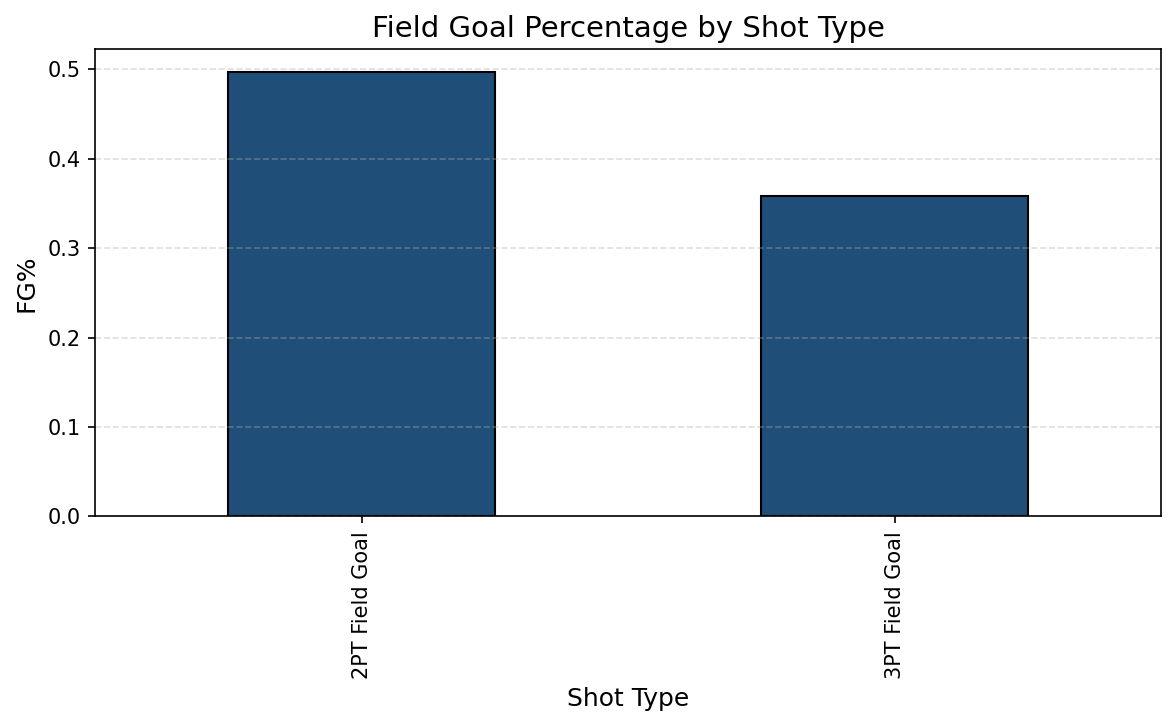

In [71]:
# FG% by shot type
fg_by_type = (
    shots.groupby("SHOT_TYPE")["SHOT_MADE"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
fg_by_type.plot(kind="bar", color=MAIN_COLOR, edgecolor="black")

plt.title("Field Goal Percentage by Shot Type")
plt.ylabel("FG%")
plt.xlabel("Shot Type")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("../figures/fg_by_shot_type.png")
plt.show()

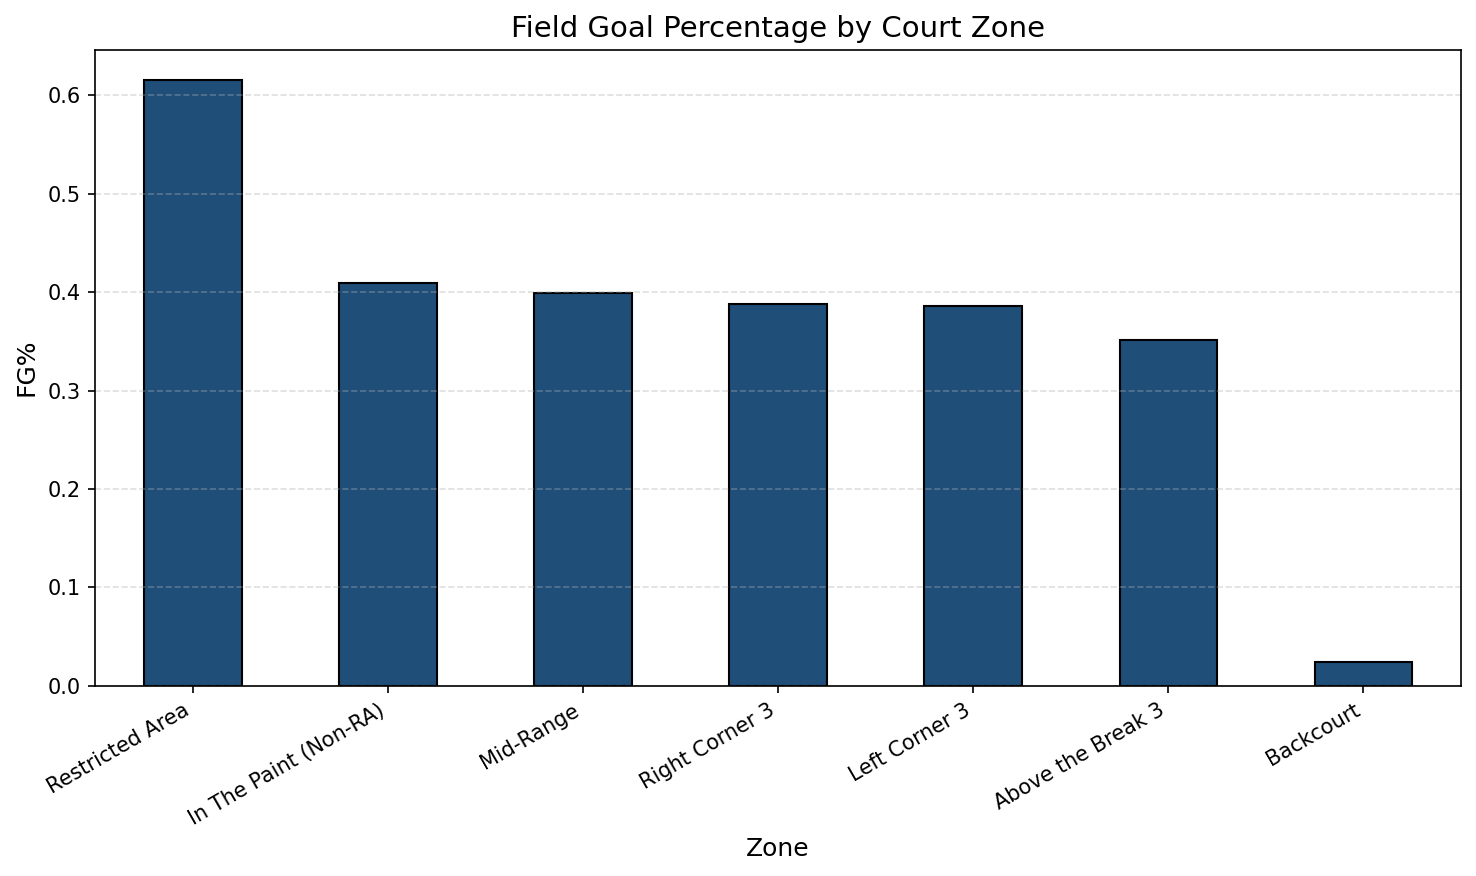

In [72]:
# FG% by basic zone
fg_by_zone = (
    shots.groupby("BASIC_ZONE")["SHOT_MADE"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
fg_by_zone.plot(kind="bar", color=MAIN_COLOR, edgecolor="black")


plt.title("Field Goal Percentage by Court Zone")
plt.ylabel("FG%")
plt.xlabel("Zone")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("../figures/fg_by_zone.png")
plt.show()

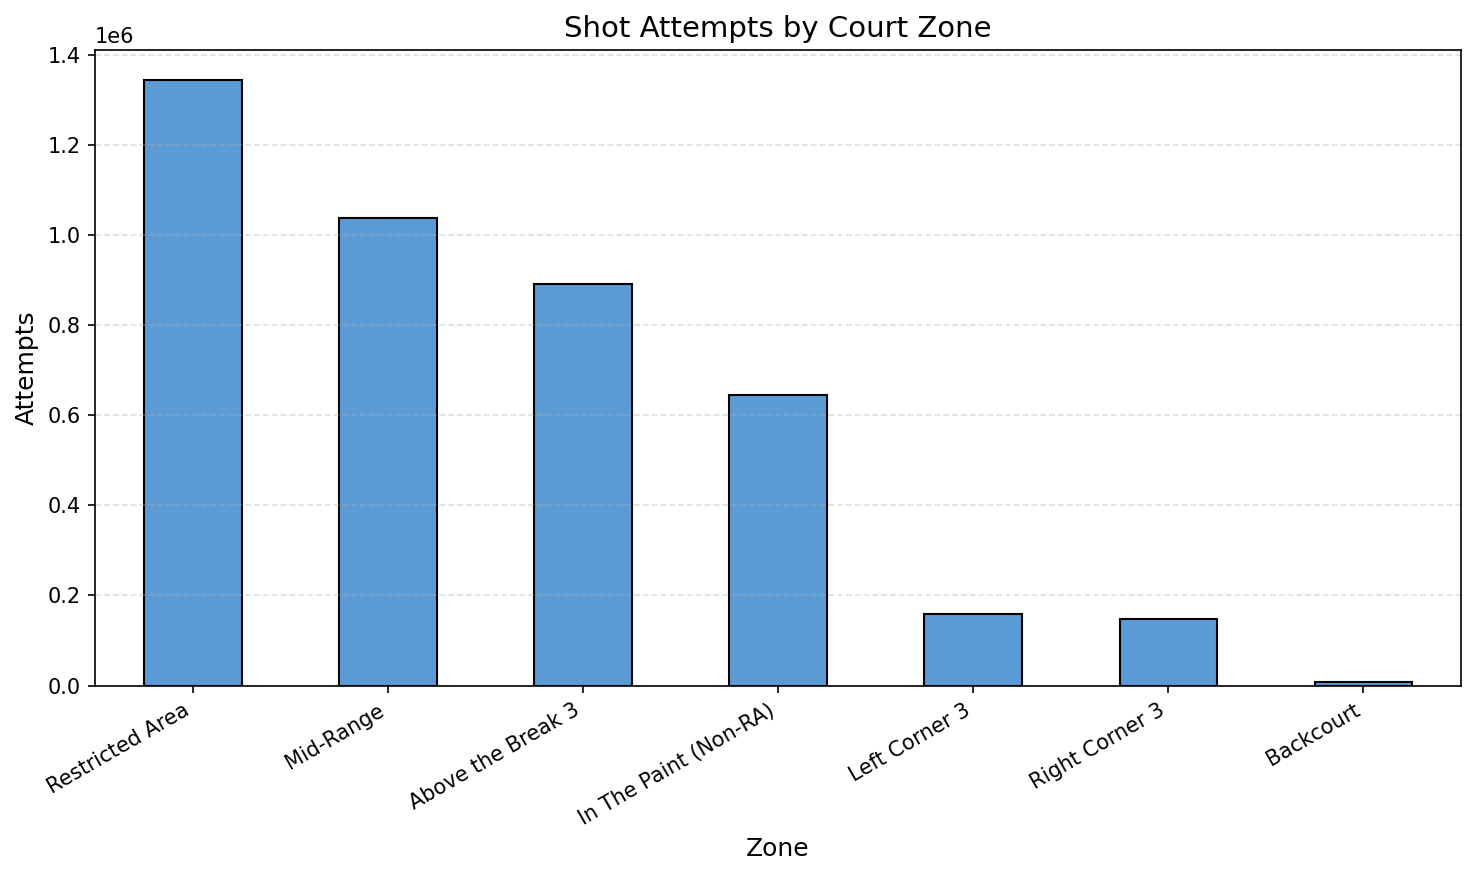

In [73]:
# Shot volume by zone
zone_counts = shots["BASIC_ZONE"].value_counts()

plt.figure(figsize=(10,6))
zone_counts.plot(kind="bar", color="#5b9bd5", edgecolor="black"
)

plt.title("Shot Attempts by Court Zone")
plt.ylabel("Attempts")
plt.xlabel("Zone")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("../figures/shot_volume_zone.png")
plt.show()

In [46]:
model_df = shots.copy()

model_df = model_df.dropna(
    subset=[
        "POSITION",
        "POSITION_GROUP"
    ]
)

features = [
    "SHOT_DISTANCE",
    "LOC_X",
    "LOC_Y",
    "SHOT_TYPE",
    "ACTION_TYPE",
    "BASIC_ZONE",
    "ZONE_NAME",
    "ZONE_ABB",
    "ZONE_RANGE",
    "QUARTER",
    "MINS_LEFT",
    "SECS_LEFT",
    "POSITION",
    "POSITION_GROUP"
]

target = "SHOT_MADE"

model_df = model_df[features + [target]]

print(model_df.shape)

(4223332, 15)


In [47]:
# Sample 500k shots for modeling
sample_df = model_df.sample(n=500000, random_state=42)

print(sample_df.shape)

(500000, 15)


In [48]:
X = sample_df.drop("SHOT_MADE", axis=1)
y = sample_df["SHOT_MADE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(400000, 14)
(100000, 14)


In [49]:
categorical_features = [
    "SHOT_TYPE",
    "ACTION_TYPE",
    "BASIC_ZONE",
    "ZONE_NAME",
    "ZONE_ABB",
    "ZONE_RANGE",
    "POSITION",
    "POSITION_GROUP"
]

numerical_features = [
    "SHOT_DISTANCE",
    "LOC_X",
    "LOC_Y",
    "QUARTER",
    "MINS_LEFT",
    "SECS_LEFT"
]

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [51]:
# Logistic Regression Pipeline
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)

c:\Users\lucie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['SHOT_DISTANCE','LOC_X','LOC_Y',...,'SECS_LEFT','POSITION', 'POSITION_GROUP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'`

In [52]:
preds = log_reg.predict(X_test)
probs = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("F1:", f1_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.62909
F1: 0.4778636485211932
ROC AUC: 0.6602179246565776


In [53]:
# Majority class baseline
majority_pred = np.zeros_like(y_test)

print("Majority Baseline")
print("Accuracy:", accuracy_score(y_test, majority_pred))
print("F1:", f1_score(y_test, majority_pred))
print("ROC AUC:", 0.5)

Majority Baseline
Accuracy: 0.5414
F1: 0.0
ROC AUC: 0.5


In [54]:
# Decision Tree Pipeline
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=12, random_state=42))
    ]
)

tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)
tree_probs = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, tree_preds))
print("F1:", f1_score(y_test, tree_preds))
print("ROC AUC:", roc_auc_score(y_test, tree_probs))

Decision Tree
Accuracy: 0.63088
F1: 0.5196376981338331
ROC AUC: 0.6625651117960558


In [55]:
# Random Forest Pipeline
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=15,
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['SHOT_DISTANCE','LOC_X','LOC_Y',...,'SECS_LEFT','POSITION', 'POSITION_GROUP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'`

In [56]:
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("F1:", f1_score(y_test, rf_preds))
print("ROC AUC:", roc_auc_score(y_test, rf_probs))

Random Forest
Accuracy: 0.63443
F1: 0.5099663543384136
ROC AUC: 0.6711808817362427


In [57]:
# PLAYER_NAME feature analysis
features_player = [
    "SHOT_DISTANCE",
    "LOC_X",
    "LOC_Y",
    "SHOT_TYPE",
    "ACTION_TYPE",
    "BASIC_ZONE",
    "ZONE_NAME",
    "ZONE_ABB",
    "ZONE_RANGE",
    "QUARTER",
    "MINS_LEFT",
    "SECS_LEFT",
    "POSITION",
    "POSITION_GROUP",
    "PLAYER_NAME"
]

model_df_player = shots.dropna(subset=["POSITION", "POSITION_GROUP", "PLAYER_NAME"])
model_df_player = model_df_player[features_player + ["SHOT_MADE"]]

sample_df_player = model_df_player.sample(n=500000, random_state=42)

print(sample_df_player.shape)

(500000, 16)


In [58]:
X_player = sample_df_player.drop("SHOT_MADE", axis=1)
y_player = sample_df_player["SHOT_MADE"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_player,
    y_player,
    test_size=0.2,
    random_state=42,
    stratify=y_player
)

print(X_train_p.shape)
print(X_test_p.shape)

(400000, 15)
(100000, 15)


In [59]:
categorical_features_player = [
    "SHOT_TYPE",
    "ACTION_TYPE",
    "BASIC_ZONE",
    "ZONE_NAME",
    "ZONE_ABB",
    "ZONE_RANGE",
    "POSITION",
    "POSITION_GROUP",
    "PLAYER_NAME"
]

numerical_features_player = [
    "SHOT_DISTANCE",
    "LOC_X",
    "LOC_Y",
    "QUARTER",
    "MINS_LEFT",
    "SECS_LEFT"
]

preprocessor_player = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_player),
        ("num", "passthrough", numerical_features_player)
    ]
)

In [60]:
rf_player_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_player),
        ("model", RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42))
    ]
)

rf_player_model.fit(X_train_p, y_train_p)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['SHOT_DISTANCE','LOC_X','LOC_Y',...,'POSITION','POSITION_GROUP', 'PLAYER_NAME']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [61]:
rf_player_preds = rf_player_model.predict(X_test_p)
rf_player_probs = rf_player_model.predict_proba(X_test_p)[:, 1]

print("Random Forest with PLAYER_NAME")
print("Accuracy:", accuracy_score(y_test_p, rf_player_preds))
print("F1:", f1_score(y_test_p, rf_player_preds))
print("ROC AUC:", roc_auc_score(y_test_p, rf_player_probs))

Random Forest with PLAYER_NAME
Accuracy: 0.62221
F1: 0.5067693713688883
ROC AUC: 0.6520252795928438


In [62]:
results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Random Forest + Player Name"
    ],
    "Accuracy": [0.54140, 0.62909, 0.63088, 0.63443, 0.62221],
    "F1": [0.00000, 0.47786, 0.51964, 0.50997, 0.50677],
    "ROC_AUC": [0.50000, 0.66022, 0.66257, 0.67118, 0.65203]
})

results

,Model,Accuracy,F1,ROC_AUC
0,Majority Baseline,0.54140,0.00000,0.50000
1,Logistic Regression,0.62909,0.47786,0.66022
2,Decision Tree,0.63088,0.51964,0.66257
3,Random Forest,0.63443,0.50997,0.67118
4,Random Forest + Player Name,0.62221,0.50677,0.65203


In [63]:
# Feature importance for final Random Forest model
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
116,num__SHOT_DISTANCE,0.152245
32,cat__ACTION_TYPE_Jump Shot,0.122912
118,num__LOC_Y,0.111036
33,cat__ACTION_TYPE_Layup Shot,0.070669
77,cat__BASIC_ZONE_Restricted Area,0.067292
117,num__LOC_X,0.056499
121,num__SECS_LEFT,0.044728
95,cat__ZONE_RANGE_Less Than 8 ft.,0.033708
120,num__MINS_LEFT,0.032025
20,cat__ACTION_TYPE_Dunk Shot,0.025152


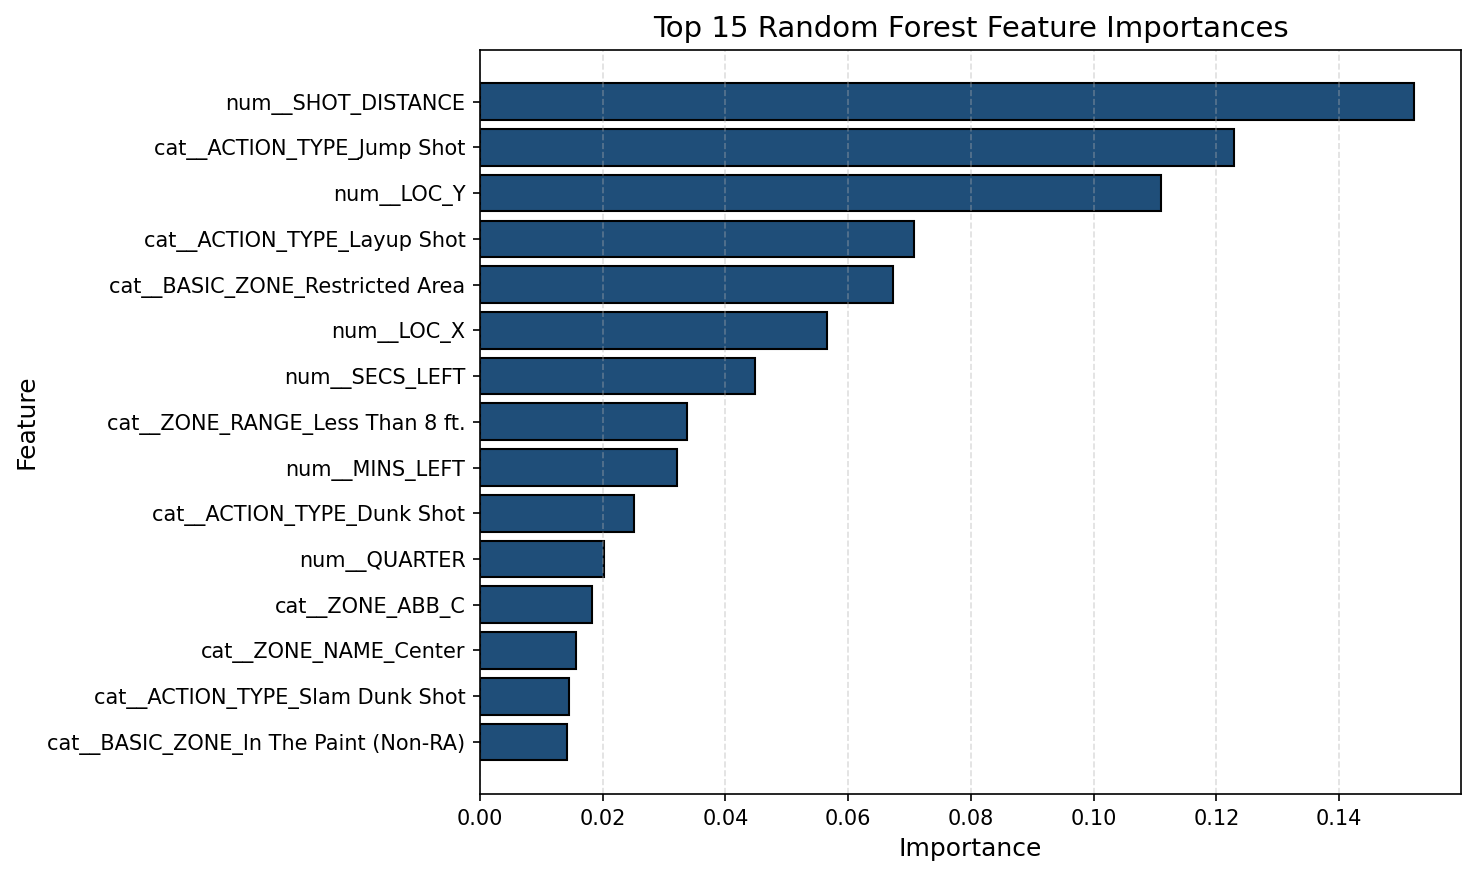

In [74]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color=MAIN_COLOR, edgecolor="black")
plt.gca().invert_yaxis()

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("../figures/random_forest_feature_importance.png")
plt.show()

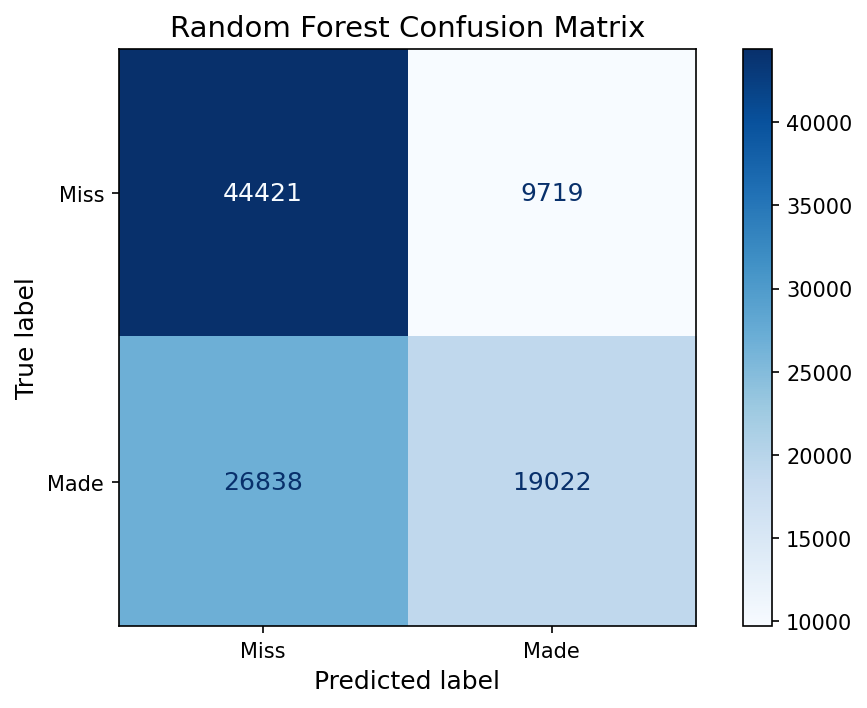

In [75]:
# Confusion matrix for final Random Forest model
cm = confusion_matrix(y_test, rf_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Miss", "Made"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.savefig("../figures/confusion_matrix_rf.png")
plt.show()

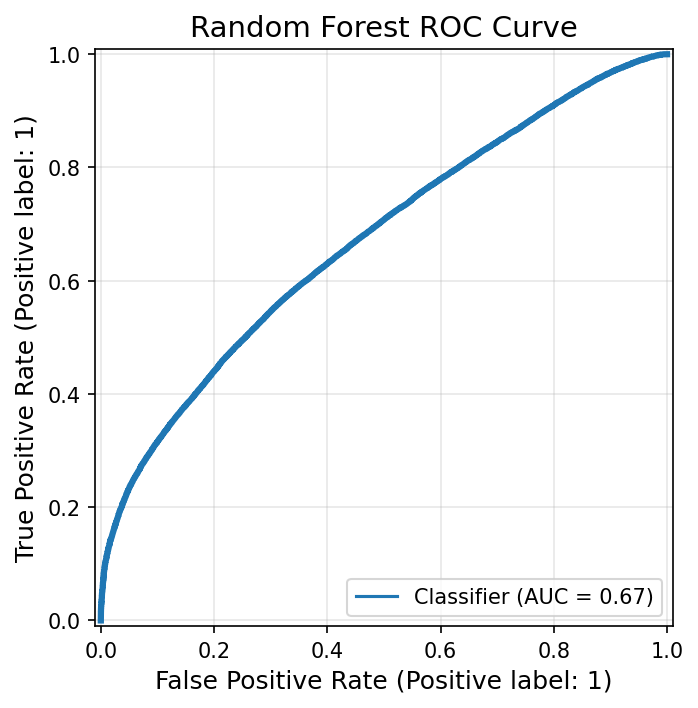

In [76]:
RocCurveDisplay.from_predictions(y_test, rf_probs)
plt.gca().lines[0].set_linewidth(3)
plt.grid(alpha=0.3)
plt.title("Random Forest ROC Curve")
plt.savefig("../figures/roc_curve_rf.png")
plt.show()